
# Crop Recommendation AI - EDA, Model Selection & Training

## Objective
Build an explainable crop recommendation model that helps agricultural extension agents recommend suitable crops based on soil and environmental conditions.

The workflow covers:
1. Data exploration and cleaning
2. Feature analysis
3. Model comparison
4. Model validation
5. Final model training
6. Saving model for Streamlit deployment


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import joblib


## 1. Load Dataset

In [2]:

df = pd.read_csv("original_dataset.csv")

df.head()


,N,P,K,temperature,humidity,ph,rainfall,soil,crop_label
0,40,27,45,21.66,94.79,5.89,112.43,sandy loam,guinea_corn
1,120,7,47,24.25,83.04,6.65,54.77,loamy clay,pepper
2,102,11,47,27.99,92.78,6.50,27.15,sandy loam,tomatoes
3,5,25,6,30.72,94.01,6.01,106.81,loamy,orange
4,36,43,21,28.36,84.86,7.14,52.93,loamy,yam


## 2. Dataset Overview

In [3]:

print(df.shape)
df.info()
df.describe()


(5000, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            5000 non-null   int64  
 1   P            5000 non-null   int64  
 2   K            5000 non-null   int64  
 3   temperature  5000 non-null   float64
 4   humidity     5000 non-null   float64
 5   ph           5000 non-null   float64
 6   rainfall     5000 non-null   float64
 7   soil         5000 non-null   object 
 8   crop_label   5000 non-null   object 
dtypes: float64(4), int64(3), object(2)
memory usage: 351.7+ KB


,N,P,K,temperature,humidity,ph,rainfall
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,51.226400,40.841600,36.242000,23.772518,68.377278,6.559738,91.334658
std,34.969383,22.755133,21.174662,4.563245,28.676976,0.650217,55.271848
min,0.000000,5.000000,5.000000,10.010000,14.260000,5.010000,20.210000
25%,22.000000,20.000000,19.000000,19.867500,59.250000,6.100000,56.020000
50%,39.000000,41.000000,36.000000,24.365000,83.120000,6.500000,80.110000
75%,84.000000,60.000000,49.000000,27.445000,90.020000,6.950000,108.480000
max,120.000000,80.000000,85.000000,34.950000,95.000000,8.870000,298.560000



## Data Quality Assessment

Duplicate observations are removed before training to avoid inflated validation performance.


In [4]:

print("Duplicate rows:", df.duplicated().sum())

df_clean = df.drop_duplicates().reset_index(drop=True)

df_clean.rename(
    columns={"soil":"soil_texture"},
    inplace=True
)

print(df_clean.shape)


Duplicate rows: 4000
(1000, 9)


## 3. Exploratory Data Analysis

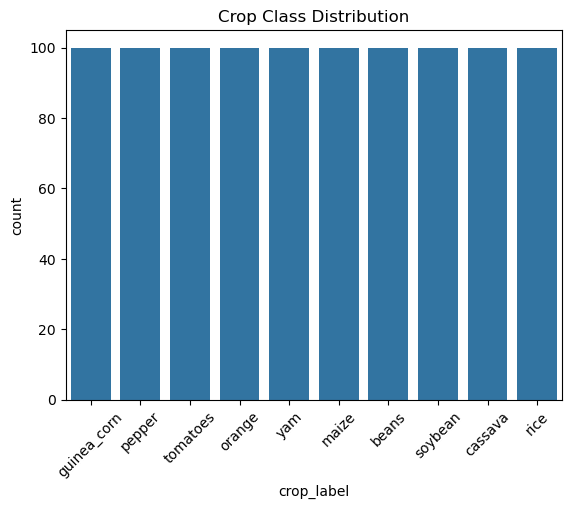

In [5]:

sns.countplot(
    data=df_clean,
    x="crop_label"
)

plt.xticks(rotation=45)
plt.title("Crop Class Distribution")
plt.show()


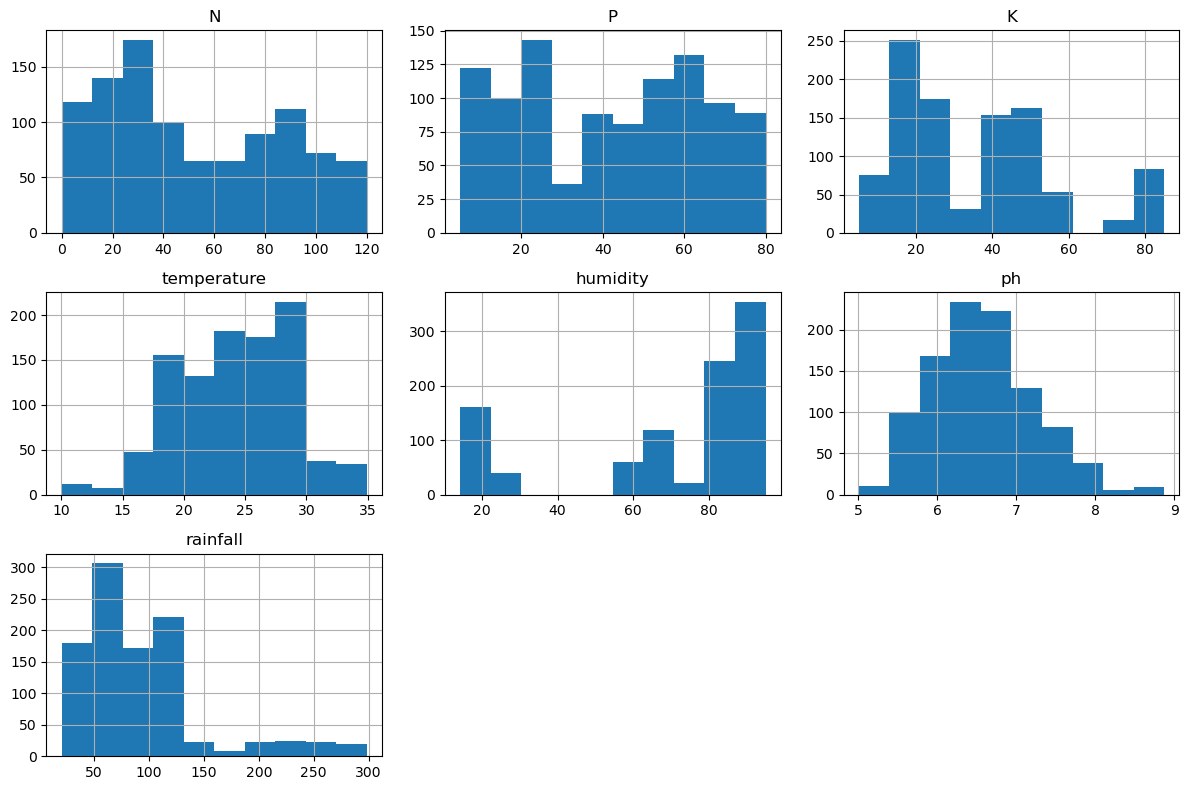

In [6]:

numeric_features = [
    "N","P","K",
    "temperature",
    "humidity",
    "ph",
    "rainfall"
]

df_clean[numeric_features].hist(figsize=(12,8))
plt.tight_layout()
plt.show()


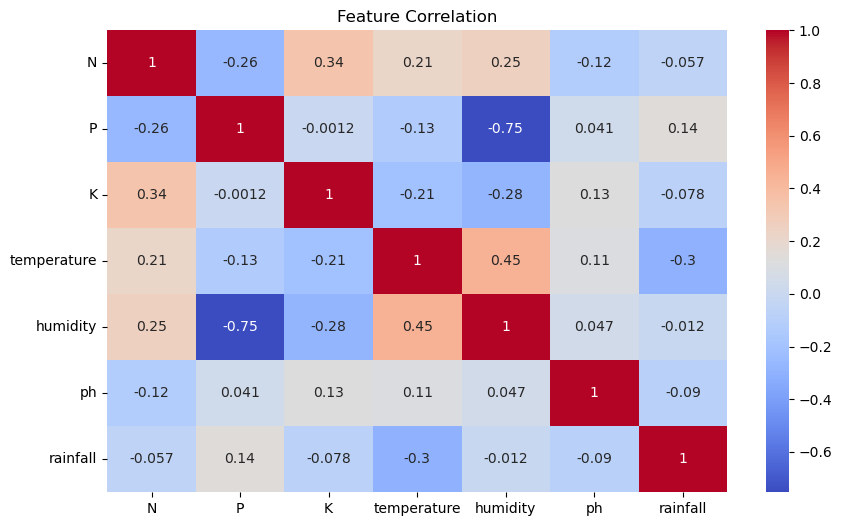

In [7]:

plt.figure(figsize=(10,6))

sns.heatmap(
    df_clean[numeric_features].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation")
plt.show()



## Agricultural Interpretation

The model uses soil nutrients (Nitrogen, Phosphorus and Potassium), soil texture and environmental factors.

Examples:
- Nitrogen supports leaf growth and influences crop suitability.
- Phosphorus supports root development.
- Potassium improves plant resilience.
- Rainfall and humidity influence water availability.
- Soil texture affects drainage and nutrient retention.


## 4. Model Training & Comparison

In [8]:

X = df_clean.drop("crop_label", axis=1)
y = df_clean["crop_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "soil",
            OneHotEncoder(handle_unknown="ignore"),
            ["soil_texture"]
        )
    ],
    remainder="passthrough"
)


models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "SVM": SVC(
        probability=True,
        random_state=42
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=1000
    )
}


results = {}

for name, model in models.items():

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    pred = pipe.predict(X_test)

    results[name] = {
        "Accuracy": accuracy_score(y_test,pred),
        "F1 Score": f1_score(
            y_test,
            pred,
            average="weighted"
        )
    }


pd.DataFrame(results).T


,Accuracy,F1 Score
Random Forest,1.0,1.0
Gradient Boosting,1.0,1.0
SVM,1.0,1.0
Logistic Regression,1.0,1.0



## 5. Final Model

Random Forest is selected because it:
- handles nonlinear agricultural relationships;
- provides probability scores for top recommendations;
- provides feature importance for explainability.


In [9]:

final_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        RandomForestClassifier(
            n_estimators=300,
            random_state=42
        )
    )
])


final_model.fit(
    X_train,
    y_train
)


predictions = final_model.predict(X_test)


print(
    classification_report(
        y_test,
        predictions
    )
)


              precision    recall  f1-score   support

       beans       1.00      1.00      1.00        20
     cassava       1.00      1.00      1.00        20
 guinea_corn       1.00      1.00      1.00        20
       maize       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20
      pepper       1.00      1.00      1.00        20
        rice       1.00      1.00      1.00        20
     soybean       1.00      1.00      1.00        20
    tomatoes       1.00      1.00      1.00        20
         yam       1.00      1.00      1.00        20

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



## Feature Importance

In [10]:

rf = final_model.named_steps["model"]

feature_names = (
    final_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.feature_importances_
})


importance.sort_values(
    "Importance",
    ascending=False
).head(15)


,Feature,Importance
10,remainder__rainfall,0.172082
8,remainder__humidity,0.136849
6,remainder__K,0.130961
4,remainder__N,0.105525
5,remainder__P,0.093018
3,soil__soil_texture_sandy loam,0.080686
1,soil__soil_texture_loamy,0.074645
7,remainder__temperature,0.068444
0,soil__soil_texture_clay,0.063376
2,soil__soil_texture_loamy clay,0.051127


In [11]:

joblib.dump(
    final_model,
    "crop_prediction_model.pkl"
)


['crop_prediction_model.pkl']